<div style="border:1px solid black; padding:10px 10px;">
    <strong>CIVIL-321 "Modélisation Numérique des Solides et Structures"</strong><br/><br/>
    <span style="text-decoration:underline;font-weight:bold;">Comment utiliser ce Jupyter Notebook?
    </span><br/><br/>
    Ce <strong>Notebook</strong> est constitué de cellules de texte et de cellule de code. Les cellules de codes doivent être  <strong>executées</strong> pour voir le résultat du programme. Certaines cellules doivent être remplies par vos soins. Pour exécuter une cellule, cliquez dessus simplement et ensuite cliquez sur le bouton "play" (<span style="font: bold 12px/30px Arial, serif;">&#9658;</span>) dans la barre de menu au dessus du notebook. Vous pouvez aussi taper la combinaison de touches <code>shift + enter</code>. Il est important d'éxécuter les cellules de code en respectant leur ordre d'arrivée dans le notebook.
</div>

On vous encourage à poser vos questions et donner votre feedback sur ce notebook sur la plateforme ED Discussion du cours accessible en cliquant sur ce bouton:
 
 
 
<div class="container" >
        <a href="https://edstem.org/eu/courses/409/discussion?category=Exercices">
            <button class="btn btn-primary btn-lg">Ed Discussion</button>
        </a>
</div>

In [1]:
import numpy as np
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from utils import *
from plot import *

/Users/romain/miniconda3/envs/MNSS/lib/python3.11/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# T3 iso-paramétrique complet

Pour cet exercice, nous allons nous construire un code iso-paramétrique complet.

## Maillage

![](Images/poutre_console.svg)
<center>*Poutre à mailler. Épaisseur $t = 10$ mm. $E = 210$ GPa, $\nu = 0.3$.*</center>

#### Question 

A partir de cette description géométrique, veuillez créer un maillage de T3, à l'aide de la fonction `meshGeo`, puis affiche le avec la fonction `plotMesh`

In [2]:
help(meshGeo)
help(plotMesh)

Help on function meshGeo in module plot:

meshGeo(filename, dim=2, order=1)
    Generates a mesh using gmsh and returns the mesh read from the generated file.

Help on function plotMesh in module plot:

plotMesh(coords, connectivity, nodal_field=None, elemental_field=None, **kwargs)



Info    : Running 'gmsh -2 -order 1 -o tmp.msh poutre.geo' [Gmsh 4.11.0, 1 node, max. 1 thread]
Info    : Started on Wed Apr 15 13:17:22 2026
Info    : Reading 'poutre.geo'...
Info    : Done reading 'poutre.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000182s, CPU 0.000122s)
Info    : Meshing 2D...
Info    : Meshing surface 6 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00110246s, CPU 0.000779s)
Info    : 96 nodes 194 elements
Info    : Writing 'tmp.msh'...
Info    : Done writing 'tmp.msh'
Info    : Stopped on Wed Apr 15 13:17:22 2026 (From start: Wall 0.00405708s, CPU 0.067691s)
Mesh generated



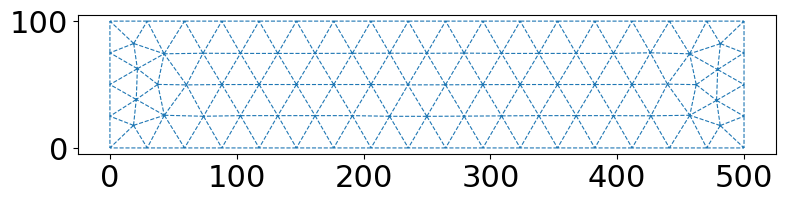

In [ ]:
# SolutionToRemove

geo_file = """
lc = DefineNumber[ 30, Name "Parameters/lc" ];
Point(1) = {0, 0, 0, lc};
Point(2) = {500, 0, 0, lc};
Point(3) = {500, 100, 0, lc};
Point(4) = {0, 100, 0, lc};
Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line Loop(5) = {3, 4, 1, 2};    
Plane Surface(6) = {5};
"""
# Line Loop should be in order so that the nodes follow in a correct order, ends on the first one, multiple possibilities like 1, 2, 3, 4 -> 1 < 2 < 3 < 4 < 1

open("poutre.geo", 'w').write(geo_file)

points, conn = meshGeo('poutre.geo', order=1) # order 1 for T3
plotMesh(points, conn)

## Matrice de rigidité

#### Question

**La pluspart des routines ci-dessous vous sont données. Veuillez les lire avec attention!**

Pour faire fonctionner le code avec les éléments T3, il faut:

- implémenter l'intégration de Gauss de la matrice locale de rigidité (fonction `calculerMatriceRigiditeLocale`):

$$[K] = \iint_e [B]^T[D][B]det(J) ds dt$$

  ce qui comprend `calculerD` (loi de constitution), `calculerC` (calcul des gradients dans l'espace naturel), `calculerBetJ` (calcul de la matrice $B$ et de la jacobienne $J$) et enfin `calculerMatriceRigiditeLocale` qui procède à l'intégration numérique.

In [4]:
def calculerD(contraintes_planes=True):
    
    E = 210e3 # 210GPa = 210e9 N/m^2 = 210e3 N/mm^2
    nu = 0.3    

    # On fait des contraintes planes par défaut
    if contraintes_planes:
        D = (E/(1-nu**2))* np.array(
            [[1,  nu, 0],
             [nu, 1,  0],
             [0,  0,  (1-nu)/2]])
    else:
        raise RuntimeError('Déformations planes à implémenter!')
    return D

def calculerC():
    N1s, N1t = [-1, -1]
    N2s, N2t = [1, 0]
    N3s, N3t = [0, 1]
    C = np.array([
        [N1s, 0, N2s, 0, N3s, 0],
        [N1t, 0, N2t, 0, N3t, 0],
        [0, N1s, 0, N2s, 0, N3s],
        [0, N1t, 0, N2t, 0, N3t]])
    return C

def calculerBetJ(x, noeuds):
    C = calculerC()

    grads = C@noeuds.ravel()
    J = np.array([[grads[0], grads[2]],
                  [grads[1], grads[3]]])
    
    
    # Définition de A
    A = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 1, 0]
    ])

    # Définition de la matrice contenant les Jacobiennes
    Jblock = np.zeros((4, 4))
    Jblock[:2, :2] = J
    Jblock[2:, 2:] = J
    
    Mat_J = np.linalg.inv(Jblock)
    B = A@Mat_J@C
    return B, J


def calculerMatriceRigiditeLocale(connectivite_element, coordonnees):
    
    quads = [[1/3, 1/3]]
    weights = [1/2]
    
    noeuds = coordonnees[connectivite_element.ravel(), :] # les noeuds de l'élément traité
    K_local = np.zeros((6, 6)) # 6x6 for T3 only
    
    for x_q, w_q in zip(quads, weights):
        B, J = calculerBetJ(x_q, noeuds)  # calcule B et J sur le point de quadrature x_q
        detJ = np.linalg.det(J)           # calcule det(J) pour l'intégration
        D = calculerD()                   # calcule la loi de constitution D
           
        # somme la quadrature avec le poid w_q
        K_local = K_local + w_q * B.T@D@B * detJ
        
    # l'épaisseur
    t = 10. # mm
    
    return t*K_local

- Procéder à l'assemblage de la matrice de rigidité complète qui comprend le calcul des numéros d'équation (fonction `calculerNumerosEquations`), et l'assemblage lui même (fonction `assemblerMatriceRigidite`)

In [5]:
        
def calculerNumerosEquations(connectivite):

    n_elem  = connectivite.shape[0]
    n_nodes_per_elem = connectivite.shape[1]
    numEq = np.zeros((n_elem, 2*n_nodes_per_elem), dtype=int)
    for e in range(n_elem):
        for i in range(n_nodes_per_elem):
            numEq[e, 2*i]   = 2*connectivite[e, i];
            numEq[e, 2*i+1] = 2*connectivite[e, i]+1;
    return numEq

def assemblerMatriceRigidite(connectivite, coordonnees):

    n_elem  = connectivite.shape[0]
    n_nodes = coordonnees.shape[0]
    numEq = calculerNumerosEquations(connectivite)

    K = np.zeros((n_nodes*2, n_nodes*2))
    for e in range(n_elem):
        # On récupère les degrés de liberté de l'élément e
        ddl = numEq[e, :]
        # On récupère les noeuds de l'élément e
        connectivite_element = connectivite[e, :]
        # On calcule la matrice de rigidite locale de l'élément e
        K_locale = calculerMatriceRigiditeLocale(connectivite_element, coordonnees)
        # On assemble
        for i, gi in enumerate(ddl):
            for j, gj in enumerate(ddl):
                K[gi, gj] += K_locale[i, j]
    return K

#### Question

Construisez la matrice de rigidité et observez son profil (utilisez la fonction `plt.spy`)

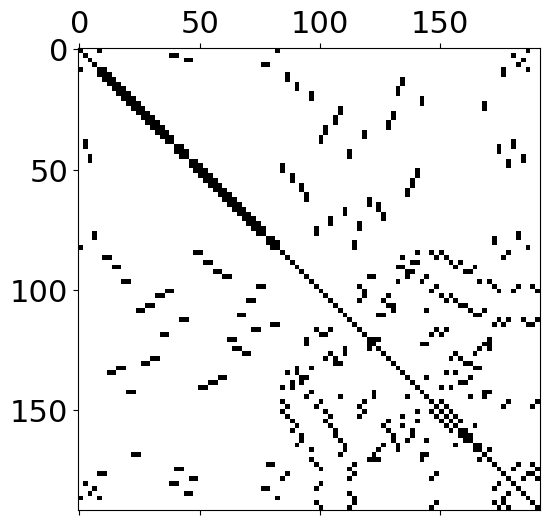

In [6]:
# SolutionToRemove

K = assemblerMatriceRigidite(conn, points)
# dessine le profile des coefficients non zero
import matplotlib.pylab as plt
plt.spy(K)

## Resolution du problème

#### Question 

Construire le vecteur des forces consistantes

In [7]:
def calculerF(nodes):
    n_nodes = nodes.shape[0]
    # On connait à l'avance le nombre de ddl
    F = np.zeros((n_nodes, 2), dtype=float)
    # faire une boucle sur les noeuds et mettre la force au bon endroit
    # ....
        
    return F.ravel()

In [8]:
# SolutionToRemove

def calculerF(nodes):
    n_nodes = nodes.shape[0]
    # On connait à l'avance le nombre de ddl
    F = np.zeros((n_nodes, 2), dtype=float)
    # faire une boucle sur les noeuds et mettre la force au bon endroit
    for index, node in enumerate(nodes):
        if (node[0] == 500 and node[1] == 100):
            F[index, 1] = -100
    return F.ravel()

F = calculerF(points)

#### Question

Construire le vecteur des blocages (fonction `calculerBlocages`)

In [ ]:
# def calculerBlocages(nodes):
#     n_nodes = nodes.shape[0]
#     # On connait à l'avance le nombre de ddl bloqués
#     blocages = np.zeros((n_nodes, 2), dtype=bool)
#     # faire une boucle sur les noeuds et mettre True quand bloqué
#     # ....
        
#     return blocages.ravel()

# blocages = calculerBlocages(points)
# libres = np.logical_not(blocages)
# libres

In [10]:
# SolutionToRemove

def calculerBlocages(nodes):
    n_nodes = nodes.shape[0]
    # On connait à l'avance le nombre de ddl bloqués
    blocages = np.zeros((n_nodes, 2), dtype=bool)
    # faire une boucle sur les noeuds et mettre True quand bloqué
    for index, node in enumerate(nodes):
        if node[0] == 0:
            blocages[index, :] = True
        
    return blocages.ravel()

blocages = calculerBlocages(points)
libres = np.logical_not(blocages)
libres

array([False, False,  True,  True,  True,  True, False, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

#### Question 

Résoudre le problème et affichez la déformée (avec la fonction `plotMesh`)

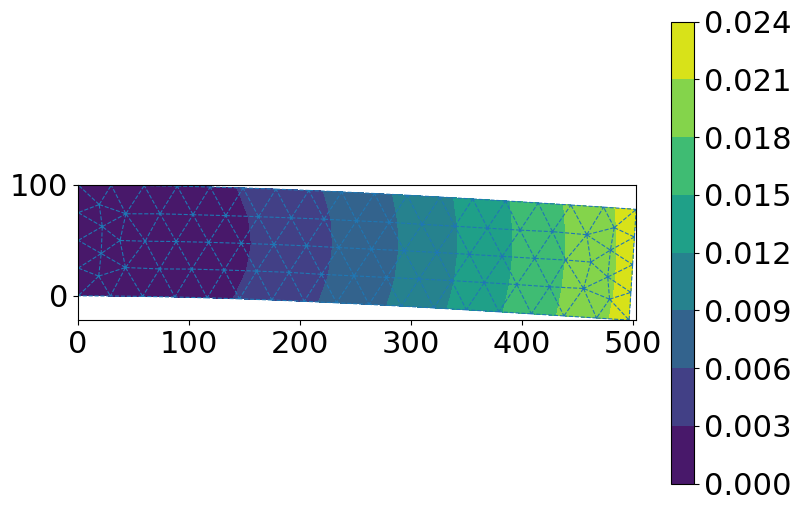

In [11]:
# SolutionToRemove

# Résolution du système Ku=F avec conditions limites
n_nodes = points.shape[0]
u = np.zeros(n_nodes*2)
u[libres] = np.linalg.solve(K[libres, :][:, libres], F[libres])

plotMesh(points+u.reshape(n_nodes, 2)*1000, conn, u)